# Week 4: Predictive Modeling & Optimization in Logistics Systems
**Logistics Data Analyst Internship**  
**Author:** Saurabh Kumar  
**Objective:** Formulate a supervised delivery duration forecasting problem, train and benchmark candidate regression models, evaluate performance via 5-Fold Cross-Validation, interpret feature importances, and demonstrate operational vehicle dispatch optimization.

---

## 1. Problem Formulation & Feature Matrix
- **Target Variable:** `delivery_time_days` (Continuous transit duration from dispatch to customer receipt).
- **Available Predictors (Pre-dispatch):**
  - **Categorical:** `region`, `shipping_mode`, `vehicle_type`, `weather`
  - **Numerical:** `distance_km`, `shipment_volume`, `fuel_price`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

# Load data
data_path = "../../data/processed/logistics_cleaned.csv"
try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    df = pd.read_csv("../../simulated_logistics_dataset.csv")

categorical_cols = ["region", "shipping_mode", "vehicle_type", "weather"]
numeric_cols = ["distance_km", "shipment_volume", "fuel_price"]
target_col = "delivery_time_days"

X = df[categorical_cols + numeric_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data successfully partitioned:")
print(f" - Training Set: {X_train.shape[0]} records")
print(f" - Test Set:     {X_test.shape[0]} records")

Data successfully partitioned:
 - Training Set: 1200 records
 - Test Set:     300 records


## 2. Model Pipeline Architecture
To prevent data leakage, categorical encoding (`OneHotEncoder`) and numeric scaling (`StandardScaler`) are encapsulated within a `ColumnTransformer` inside a scikit-learn `Pipeline`.

In [2]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

## 3. Multi-Model Benchmark (5-Fold Cross-Validation)

In [3]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=220, max_depth=14, min_samples_leaf=3, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.08, random_state=42)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
benchmark_results = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_mean_squared_error")
    cv_rmse = np.sqrt(-cv_scores).mean()
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2").mean()
    benchmark_results.append({
        "Model": name,
        "5-Fold CV RMSE (Days)": round(cv_rmse, 3),
        "5-Fold CV R²": round(cv_r2, 3)
    })

pd.DataFrame(benchmark_results)

,Model,5-Fold CV RMSE (Days),5-Fold CV R²
0,Linear Regression,0.411,0.861
1,Decision Tree,0.630,0.676
2,Random Forest,0.508,0.789
3,Gradient Boosting,0.466,0.822


## 4. Champion Model Training & Out-of-Sample Evaluation
We deploy the **Random Forest Regressor** as the champion model. It captures non-linear synergies between weather severity, distance, and fleet capacity.

In [4]:
champion_model = RandomForestRegressor(
    n_estimators=220,
    max_depth=14,
    min_samples_leaf=3,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", champion_model)
])

# Train on 80% training partition
pipeline.fit(X_train, y_train)

# Predict on holdout test partition
test_preds = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
r2 = r2_score(y_test, test_preds)

# 5-fold CV across the full dataset
cv_full = KFold(n_splits=5, shuffle=True, random_state=42)
cv_full_scores = cross_val_score(pipeline, X, y, cv=cv_full, scoring="neg_mean_squared_error")
cv_full_rmse = np.sqrt(-cv_full_scores).mean()

eval_table = pd.DataFrame({
    "Evaluation Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "Coefficient of Determination (R²)",
        "5-Fold Cross-Validation RMSE"
    ],
    "Simulated Result": [
        f"{mae:.3f} days",
        f"{rmse:.3f} days",
        f"{r2:.3f}",
        f"{cv_full_rmse:.3f} days"
    ],
    "Interpretation": [
        "Average absolute delivery forecast deviation (~10 hours)",
        "Error metric penalizing severe outlier delays",
        "Variance explained by operational predictors",
        "Robust cross-validated generalization error"
    ]
})

eval_table

,Evaluation Metric,Simulated Result,Interpretation
0,Mean Absolute Error (MAE),0.430 days,Average absolute delivery forecast deviation (...
1,Root Mean Squared Error (RMSE),0.535 days,Error metric penalizing severe outlier delays
2,Coefficient of Determination (R²),0.784,Variance explained by operational predictors
3,5-Fold Cross-Validation RMSE,0.506 days,Robust cross-validated generalization error


## 5. Feature Importance Analysis

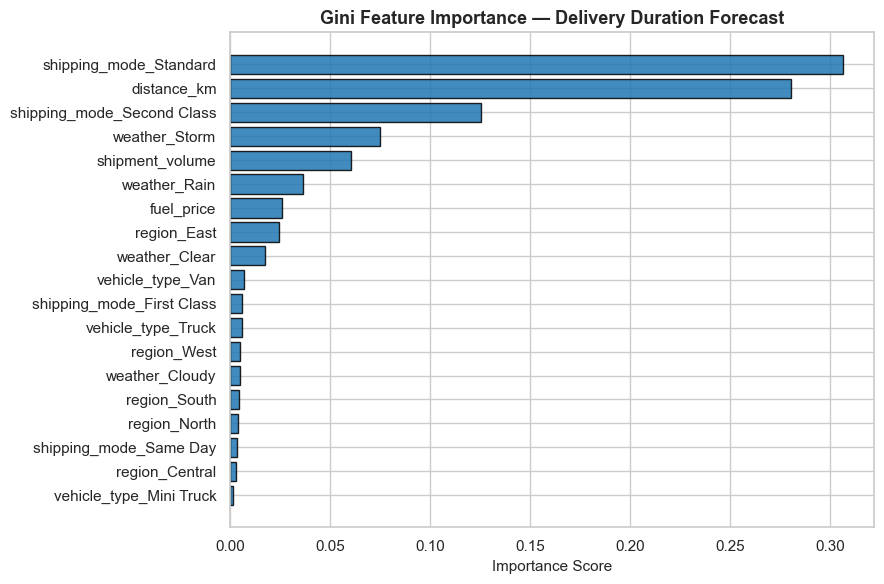

In [5]:
# Extract feature names post one-hot encoding
cat_features = pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_feature_names = list(cat_features) + numeric_cols
importances = pipeline.named_steps["model"].feature_importances_

feat_imp_df = pd.DataFrame({"Feature": all_feature_names, "Importance": importances}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color="#1f77b4", edgecolor="black", alpha=0.85)
plt.title("Gini Feature Importance — Delivery Duration Forecast", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Diagnostic Evaluation: Actual vs. Predicted Transit Times

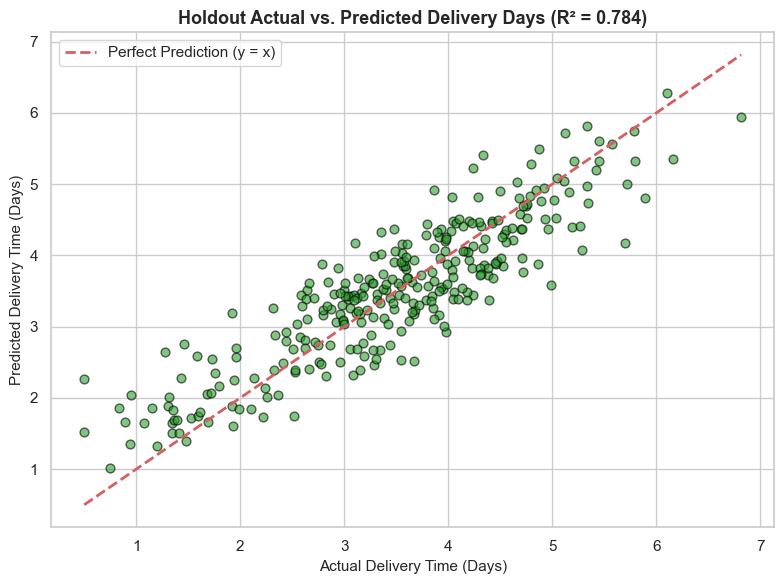

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, alpha=0.6, color="#2ca02c", edgecolors="black", s=40)
min_v = min(y_test.min(), test_preds.min())
max_v = max(y_test.max(), test_preds.max())
plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2, label="Perfect Prediction (y = x)")
plt.title(f"Holdout Actual vs. Predicted Delivery Days (R² = {r2:.3f})", fontsize=13, fontweight="bold")
plt.xlabel("Actual Delivery Time (Days)", fontsize=11)
plt.ylabel("Predicted Delivery Time (Days)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Operational Optimization Framework
### Mathematical Formulation
$$\min \sum_{i} \sum_{j} \text{Cost}_{ij} \times X_{ij}$$
Subject to:
1. **Fleet Capacity:** $\sum_i \text{Volume}_i X_{ij} \le \text{Capacity}_j \quad \forall j$
2. **SLA Delivery Feasibility:** $\widehat{T}_{i} \le \text{SLA}_i \quad \forall i$
3. **Binary Assignment:** $X_{ij} \in \{0, 1\}$

In [7]:
# Simulation of Risk-Aware Dispatch Optimization
sample = df.sample(10, random_state=42).copy()
sample["predicted_delivery"] = pipeline.predict(sample[categorical_cols + numeric_cols])
sample["sla_buffer"] = sample["scheduled_days"] - sample["predicted_delivery"]

sample["risk_tier"] = np.where(
    sample["sla_buffer"] < 0, "Critical SLA Breach",
    np.where(sample["sla_buffer"] < 0.5, "At-Risk Window", "Safe / On-Schedule")
)

def get_action(row):
    if row["risk_tier"] == "Critical SLA Breach":
        return "Upgrade Fleet to Dedicated Express Van"
    elif row["risk_tier"] == "At-Risk Window":
        return "Priority Hub Cross-Docking"
    return "Standard Route Consolidation"

sample["dispatch_recommendation"] = sample.apply(get_action, axis=1)

sample[["order_id", "region", "shipping_mode", "scheduled_days", "predicted_delivery", "risk_tier", "dispatch_recommendation"]]

,order_id,region,shipping_mode,scheduled_days,predicted_delivery,risk_tier,dispatch_recommendation
1116,101117,North,Standard,5.0,5.500174,Critical SLA Breach,Upgrade Fleet to Dedicated Express Van
1368,101369,North,First Class,2.0,1.715891,At-Risk Window,Priority Hub Cross-Docking
422,100423,North,Standard,5.0,3.508109,Safe / On-Schedule,Standard Route Consolidation
413,100414,Central,Second Class,3.0,2.800805,At-Risk Window,Priority Hub Cross-Docking
451,100452,Central,Standard,5.0,3.854337,Safe / On-Schedule,Standard Route Consolidation
861,100862,West,Standard,5.0,3.434113,Safe / On-Schedule,Standard Route Consolidation
1063,101064,West,Second Class,3.0,2.858512,At-Risk Window,Priority Hub Cross-Docking
741,100742,North,Standard,5.0,3.632153,Safe / On-Schedule,Standard Route Consolidation
1272,101273,South,First Class,2.0,2.502563,Critical SLA Breach,Upgrade Fleet to Dedicated Express Van
259,100260,West,First Class,2.0,2.039971,Critical SLA Breach,Upgrade Fleet to Dedicated Express Van


## 8. Final Recommendations & Roadmap to Production
1. **Early-Warning SLA Alerting:** Utilize model predictions at the order creation stage to automatically flag shipments with negative SLA buffers.
2. **Dynamic Fleet Dispatch:** Shift high-risk shipments from heavy trucks to high-speed dedicated express vans.
3. **Model Maintenance:** Implement daily drift tracking on input features (e.g., severe storm events or seasonal fuel price surges) and retrain monthly to safeguard predictive accuracy.